# 03 - Classification

Notebook này xây dựng mô hình phân loại nhị phân nhằm ước lượng khả năng một khách hàng viễn thông sẽ rời bỏ dịch vụ. Biến mục tiêu `Churn` được mã hóa thành `0 = No` và `1 = Yes`. Đầu ra quan trọng của mô hình không chỉ là nhãn dự đoán mà còn là xác suất churn của từng khách hàng, vì xác suất này sẽ được sử dụng để xếp hạng rủi ro và tối ưu ngưỡng quyết định ở phase tiếp theo.

Quy trình thực nghiệm gồm các bước: kiểm tra dữ liệu processed, loại bỏ biến định danh, chia train/test có stratify, xây dựng preprocessing pipeline, huấn luyện Logistic Regression và Random Forest, đánh giá trên tập test, so sánh mô hình, phân tích đặc trưng và lưu model tốt nhất.

### Mục tiêu phân tích

- Xây dựng một baseline có khả năng tái lập và không gây data leakage.
- So sánh mô hình tuyến tính dễ diễn giải với mô hình cây phi tuyến.
- Phát hiện được nhiều khách hàng churn nhất có thể nhưng vẫn kiểm soát số lượng cảnh báo sai.
- Tạo artifact có thể tái sử dụng cho bước tối ưu threshold và business optimization.

Do chi phí bỏ sót một khách hàng sắp rời bỏ thường cao hơn chi phí liên hệ nhầm một khách hàng không churn, quá trình lựa chọn mô hình ưu tiên **Recall** và **F1-score** của lớp `Churn = Yes`. Accuracy vẫn được báo cáo nhưng không được dùng làm tiêu chí duy nhất, bởi dữ liệu có khoảng 73% khách hàng không churn và một mô hình thiên về lớp đa số vẫn có thể đạt Accuracy tương đối cao.

## 1. Import thư viện và cấu hình

Phần này import các thư viện phục vụ xử lý dữ liệu, trực quan hóa, xây dựng pipeline, huấn luyện, đánh giá và lưu model. Các đường dẫn, tỷ lệ chia dữ liệu, `random_state` và hyperparameter chính được đọc từ `configs/base.yaml` và `configs/classification.yaml` thay vì viết trực tiếp trong notebook.

Cách tổ chức này đem lại ba lợi ích:

1. **Tái lập kết quả:** cùng cấu hình và `random_state=42` sẽ tạo ra cùng phép chia train/test và kết quả gần như nhất quán.
2. **Dễ bảo trì:** khi muốn đổi tỷ lệ test, số cây hoặc class weight, chỉ cần sửa file YAML.
3. **Tách biệt logic và tham số:** notebook tập trung vào quy trình phân tích, còn config lưu các lựa chọn thực nghiệm.

Thư mục `reports/` và `models/` cũng được tạo tự động nếu chưa tồn tại để bảo đảm các cell lưu kết quả không thất bại vì thiếu đường dẫn.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

with (PROJECT_ROOT / "configs" / "base.yaml").open("r", encoding="utf-8") as file:
    base_config = yaml.safe_load(file)

with (PROJECT_ROOT / "configs" / "classification.yaml").open("r", encoding="utf-8") as file:
    classification_config = yaml.safe_load(file)

RANDOM_STATE = base_config["project"]["random_state"]
REPORTS_DIR = PROJECT_ROOT / base_config["paths"]["reports_dir"]
MODELS_DIR = PROJECT_ROOT / base_config["paths"]["models_dir"]
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)

print("Project root:", PROJECT_ROOT)
print("Random state:", RANDOM_STATE)

Project root: d:\Customer-Churn-DM
Random state: 42


## 2. Load và kiểm tra dữ liệu processed

`features.csv` chứa 20 cột đầu vào, bao gồm `customerID`, còn `target.csv` chứa `customerID` và biến mục tiêu `Churn`. Hai file được tạo từ notebook Data Understanding và được xem là đầu vào chính thức của phase modeling.

Trước khi huấn luyện, notebook thực hiện các kiểm tra bắt buộc:

- Hai file phải có cùng số dòng.
- `customerID` phải khớp theo đúng thứ tự giữa features và target.
- Biến mục tiêu chỉ được chứa hai giá trị `Yes` và `No`.
- Số lượng quan sát và phân phối target phải phù hợp với kết quả ở các phase trước.

Các câu lệnh `assert` giúp notebook dừng sớm nếu dữ liệu bị lệch hoặc thay đổi ngoài dự kiến. Điều này quan trọng vì việc ghép sai target với khách hàng có thể tạo ra một mô hình chạy được về mặt kỹ thuật nhưng hoàn toàn sai về mặt phân tích.

In [2]:
features_path = PROJECT_ROOT / base_config["paths"]["features"]
target_path = PROJECT_ROOT / base_config["paths"]["target"]

features = pd.read_csv(features_path)
target = pd.read_csv(target_path)

id_column = base_config["dataset"]["id_column"]
target_column = base_config["dataset"]["target_column"]

assert len(features) == len(target), "Features và target không có cùng số dòng."
assert features[id_column].equals(target[id_column]), "customerID giữa hai file không cùng thứ tự."
assert set(target[target_column].unique()) == {"No", "Yes"}, "Target có giá trị ngoài Yes/No."

print("Features shape:", features.shape)
print("Target shape:", target.shape)
display(target[target_column].value_counts().to_frame("count"))
features.head()

Features shape: (7043, 20)
Target shape: (7043, 2)


,count
Churn,
No,5174
Yes,1869


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


### Chuẩn bị biến đầu vào và biến mục tiêu

`customerID` là mã định danh duy nhất, không mô tả hành vi hay đặc điểm kinh doanh của khách hàng. Nếu đưa vào mô hình, OneHotEncoder có thể tạo hàng nghìn biến giả vô nghĩa, làm tăng độ phức tạp và khiến model học thuộc các ID trong tập train. Vì vậy, cột này được loại khỏi `X` nhưng vẫn được giữ riêng để ghép lại với prediction trên tập test.

Biến `Churn` được mã hóa thành `No = 0` và `Yes = 1`. Quy ước lớp churn là lớp dương giúp các hàm `precision_score`, `recall_score`, `f1_score` và `predict_proba()[:, 1]` cùng tập trung vào nhóm khách hàng cần được phát hiện.

**Kiểm soát data leakage:** không sử dụng `customerID`, target hoặc bất kỳ thông tin hình thành sau thời điểm churn làm feature. Mọi bước học tham số như imputation, scaling và encoding đều được đặt bên trong pipeline và chỉ fit trên tập train.

In [3]:
customer_ids = features[id_column].copy()
X = features.drop(columns=[id_column])
y = target[target_column].map({"No": 0, "Yes": 1})

assert y.notna().all(), "Không thể mã hóa toàn bộ target."

print("Model features:", X.shape)
print("Target distribution:")
display(y.value_counts().rename(index={0: "No", 1: "Yes"}).to_frame("count"))

Model features: (7043, 19)
Target distribution:


,count
Churn,
No,5174
Yes,1869


## 3. Chia tập train và test

Dữ liệu được chia thành tập train và test theo tỷ lệ `80/20`. Tập train dùng để học preprocessing và tham số mô hình; tập test được giữ độc lập để ước lượng khả năng tổng quát hóa trên dữ liệu chưa từng quan sát.

Tham số `stratify=y` bảo đảm tỷ lệ churn khoảng 26.5% được duy trì gần tương đương ở cả hai tập. Nếu chia ngẫu nhiên mà không stratify, đặc biệt với dữ liệu mất cân bằng, một tập có thể chứa quá ít khách churn và làm metric biến động hoặc thiếu tin cậy.

`random_state=42` giúp cố định phép chia để việc so sánh Logistic Regression và Random Forest diễn ra trên cùng một tập test. Đồng thời, `customerID` cũng được chia theo đúng index với `X` và `y`, nhờ đó prediction sau cùng vẫn truy vết được về từng khách hàng.

**Nguyên tắc đánh giá:** tập test không được dùng để fit preprocessing, chọn feature hoặc điều chỉnh model nhiều lần. Trong một dự án mở rộng, hyperparameter tuning nên được thực hiện bằng cross-validation trên tập train trước khi đánh giá một lần trên test.

In [4]:
split_config = classification_config["train_test_split"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_ids,
    test_size=split_config["test_size"],
    random_state=split_config["random_state"],
    stratify=y if split_config["stratify"] else None,
)

split_summary = pd.DataFrame({
    "dataset": ["Train", "Test"],
    "rows": [len(X_train), len(X_test)],
    "churn_rate_pct": [y_train.mean() * 100, y_test.mean() * 100],
}).round(2)

display(split_summary)

,dataset,rows,churn_rate_pct
0,Train,5634,26.54
1,Test,1409,26.54


## 4. Xây dựng preprocessing pipeline

Dữ liệu Telco gồm cả biến số và biến phân loại, vì vậy không thể đưa trực tiếp toàn bộ DataFrame vào các thuật toán scikit-learn. `ColumnTransformer` được dùng để áp dụng quy trình xử lý phù hợp cho từng nhóm cột.

### Numeric pipeline

- `SimpleImputer(strategy='median')`: điền giá trị thiếu bằng trung vị của tập train. Median ít nhạy cảm với outlier hơn mean.
- `StandardScaler()`: đưa các biến số về thang đo có trung bình gần 0 và độ lệch chuẩn gần 1. Bước này đặc biệt quan trọng với Logistic Regression vì hệ số được tối ưu trên các feature có đơn vị rất khác nhau như `tenure`, `MonthlyCharges` và `TotalCharges`.

### Categorical pipeline

- `SimpleImputer(strategy='most_frequent')`: thay missing bằng category xuất hiện nhiều nhất trong tập train.
- `OneHotEncoder(handle_unknown='ignore')`: chuyển mỗi category thành biến nhị phân. Khi tập test hoặc dữ liệu mới chứa category chưa xuất hiện trong train, encoder sẽ không gây lỗi mà mã hóa category đó thành vector 0.

Toàn bộ preprocessing được đặt bên trong `Pipeline`. Khi gọi `fit(X_train, y_train)`, median, mode, mean, standard deviation và danh sách category chỉ được học từ tập train. Khi gọi `predict(X_test)`, pipeline tự động áp dụng lại đúng các phép biến đổi đã học, qua đó tránh data leakage và bảo đảm quy trình inference nhất quán.

In [5]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

preprocessing_config = classification_config["preprocessing"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy=preprocessing_config["numeric_imputer"])),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy=preprocessing_config["categorical_imputer"])),
    ("onehot", OneHotEncoder(
        handle_unknown=preprocessing_config["one_hot_handle_unknown"],
        sparse_output=True,
    )),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("Numeric features:", numeric_features)
print("Categorical feature count:", len(categorical_features))
print("Categorical features:", categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical feature count: 16
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Khởi tạo và huấn luyện mô hình

Hai thuật toán được lựa chọn để tạo một phép so sánh giữa mô hình tuyến tính dễ diễn giải và mô hình ensemble phi tuyến.

### Logistic Regression

Logistic Regression ước lượng log-odds của xác suất churn bằng tổ hợp tuyến tính của các feature sau preprocessing. Đây là baseline phù hợp vì tốc độ huấn luyện nhanh, hỗ trợ `predict_proba`, hoạt động tốt với dữ liệu one-hot và cho phép giải thích chiều tác động qua coefficient. `max_iter=1000` được sử dụng để tăng khả năng hội tụ sau khi số lượng feature mở rộng qua OneHotEncoder.

### Random Forest

Random Forest kết hợp nhiều decision tree được huấn luyện trên các bootstrap sample và tập con feature khác nhau. Mô hình có thể học quan hệ phi tuyến và interaction mà không cần khai báo thủ công, ví dụ sự kết hợp giữa hợp đồng tháng, tenure thấp và phương thức thanh toán. `n_estimators=300` giúp kết quả ổn định hơn so với một số lượng cây nhỏ.

### Xử lý mất cân bằng lớp

`class_weight='balanced'` tự động gán trọng số lớn hơn cho lớp churn dựa trên tần suất của từng lớp. Sai số trên khách hàng churn vì vậy bị phạt mạnh hơn trong quá trình học. Đây là một lựa chọn baseline đơn giản, không tạo thêm dữ liệu tổng hợp và chỉ tác động trong tập train.

In [6]:
model_config = classification_config["models"]

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=model_config["logistic_regression"]["max_iter"],
        class_weight=model_config["logistic_regression"]["class_weight"],
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=model_config["random_forest"]["n_estimators"],
        max_depth=model_config["random_forest"]["max_depth"],
        class_weight=model_config["random_forest"]["class_weight"],
        random_state=model_config["random_forest"]["random_state"],
        n_jobs=-1,
    ),
}

fitted_pipelines = {}

for model_name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline
    print(f"Trained: {model_name}")

Trained: Logistic Regression
Trained: Random Forest


## 6. Đánh giá và so sánh mô hình

Mỗi mô hình tạo xác suất churn và chuyển xác suất thành nhãn tại threshold mặc định `0.5`. Các metric dưới đây phản ánh những khía cạnh khác nhau của chất lượng mô hình:

- **Accuracy:** tỷ lệ dự đoán đúng trên toàn bộ tập test. Metric này dễ hiểu nhưng có thể gây hiểu nhầm khi lớp không cân bằng.
- **Precision - Churn Yes:** trong số khách hàng bị model flag churn, bao nhiêu người thực sự churn. Precision thấp làm tăng chi phí liên hệ hoặc ưu đãi nhầm.
- **Recall - Churn Yes:** trong số khách hàng thực sự churn, model phát hiện được bao nhiêu người. Recall thấp đồng nghĩa doanh nghiệp bỏ sót nhiều cơ hội giữ chân.
- **F1-score - Churn Yes:** trung bình điều hòa của Precision và Recall, phù hợp khi cần cân bằng cả hai loại sai số.
- **ROC-AUC:** khả năng xếp khách churn ở mức rủi ro cao hơn khách không churn trên nhiều threshold. AUC không phụ thuộc một threshold duy nhất.

Kết quả cho thấy Logistic Regression đạt Recall churn khoảng **78.3%**, F1 khoảng **61.4%** và ROC-AUC khoảng **84.2%**. Random Forest có Accuracy và Precision cao hơn nhưng Recall churn chỉ khoảng **47.1%**, nghĩa là bỏ sót hơn một nửa khách hàng churn trong tập test. Với mục tiêu ưu tiên phát hiện churn, Logistic Regression phù hợp hơn ở giai đoạn này dù số cảnh báo sai cao hơn.

In [7]:
evaluation_rows = []
predictions = {}

for model_name, pipeline in fitted_pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    predictions[model_name] = {"pred": y_pred, "proba": y_proba}

    evaluation_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_churn_yes": precision_score(y_test, y_pred, zero_division=0),
        "recall_churn_yes": recall_score(y_test, y_pred, zero_division=0),
        "f1_churn_yes": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "flagged_customers": int(y_pred.sum()),
    })

model_comparison = (
    pd.DataFrame(evaluation_rows)
    .sort_values(["f1_churn_yes", "recall_churn_yes", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(model_comparison.style.format({
    "accuracy": "{:.3f}",
    "precision_churn_yes": "{:.3f}",
    "recall_churn_yes": "{:.3f}",
    "f1_churn_yes": "{:.3f}",
    "roc_auc": "{:.3f}",
}))

model_comparison.to_csv(REPORTS_DIR / "classification_model_comparison.csv", index=False)

,model,accuracy,precision_churn_yes,recall_churn_yes,f1_churn_yes,roc_auc,flagged_customers
0,Logistic Regression,0.738,0.504,0.783,0.614,0.842,581
1,Random Forest,0.786,0.629,0.471,0.538,0.822,280


In [8]:
for model_name in fitted_pipelines:
    print(f"\n{'=' * 70}\n{model_name}\n{'=' * 70}")
    report = classification_report(
        y_test,
        predictions[model_name]["pred"],
        target_names=["No Churn", "Churn"],
        digits=3,
        zero_division=0,
    )
    print(report)


Logistic Regression
              precision    recall  f1-score   support

    No Churn      0.902     0.722     0.802      1035
       Churn      0.504     0.783     0.614       374

    accuracy                          0.738      1409
   macro avg      0.703     0.753     0.708      1409
weighted avg      0.797     0.738     0.752      1409


Random Forest
              precision    recall  f1-score   support

    No Churn      0.825     0.900     0.860      1035
       Churn      0.629     0.471     0.538       374

    accuracy                          0.786      1409
   macro avg      0.727     0.685     0.699      1409
weighted avg      0.773     0.786     0.775      1409



### Confusion matrix

Confusion matrix chia kết quả thành bốn nhóm:

- **True Negative (TN):** khách không churn và model dự đoán đúng là không churn.
- **False Positive (FP):** khách không churn nhưng bị flag churn; có thể gây chi phí chăm sóc hoặc ưu đãi không cần thiết.
- **False Negative (FN):** khách thực sự churn nhưng model dự đoán không churn; doanh nghiệp bỏ lỡ cơ hội can thiệp.
- **True Positive (TP):** khách churn được model phát hiện đúng và có thể được đưa vào chiến dịch giữ chân.

Trong bối cảnh retention, FN thường là sai số đáng quan tâm nhất. Logistic Regression chấp nhận tạo nhiều FP hơn để giảm FN và đạt Recall cao. Random Forest thận trọng hơn khi flag churn nên Precision tốt hơn, nhưng đổi lại bỏ sót nhiều khách churn hơn. Trade-off này sẽ được điều chỉnh rõ hơn bằng threshold ở phase tiếp theo.

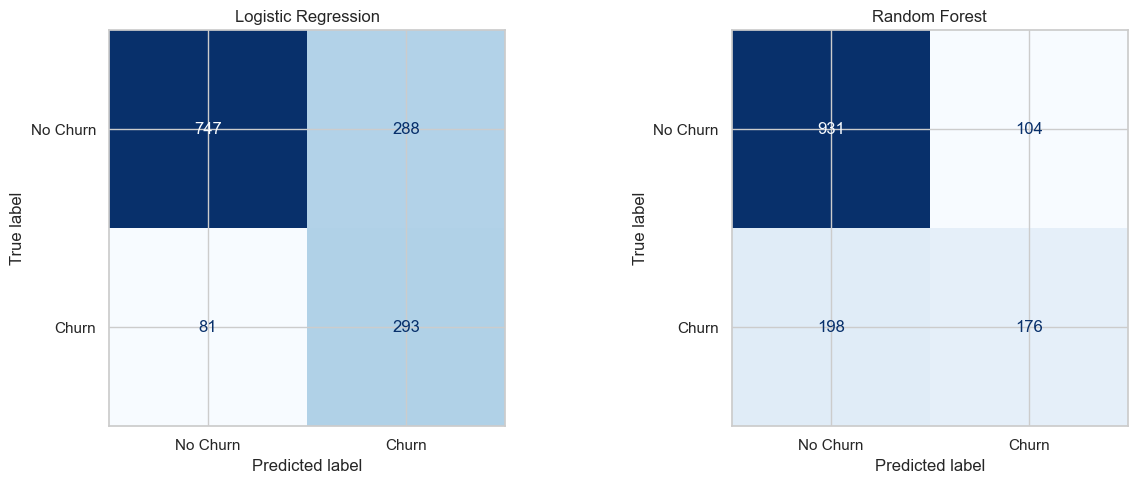

In [9]:
fig, axes = plt.subplots(1, len(fitted_pipelines), figsize=(13, 5))

for ax, model_name in zip(np.atleast_1d(axes), fitted_pipelines):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name]["pred"],
        display_labels=["No Churn", "Churn"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "classification_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### ROC curve

ROC curve biểu diễn **True Positive Rate** theo **False Positive Rate** khi threshold thay đổi từ cao xuống thấp. Đường cong càng gần góc trên bên trái thì mô hình càng phân biệt tốt hai lớp; đường chéo thể hiện mức dự đoán ngẫu nhiên.

ROC-AUC của Logistic Regression khoảng `0.842`, nghĩa là nếu chọn ngẫu nhiên một khách churn và một khách không churn, mô hình có khoảng 84.2% khả năng xếp khách churn ở mức xác suất cao hơn. Random Forest đạt khoảng `0.822`. Cả hai đều tốt hơn ngẫu nhiên, nhưng Logistic Regression có khả năng xếp hạng tổng thể tốt hơn trên tập test hiện tại.

ROC-AUC vẫn cần được đọc cùng Precision-Recall, confusion matrix và mục tiêu chi phí. Với bài toán có lớp dương ít hơn, Precision-Recall curve ở notebook 04 sẽ phản ánh trực tiếp hơn chất lượng phát hiện churn.

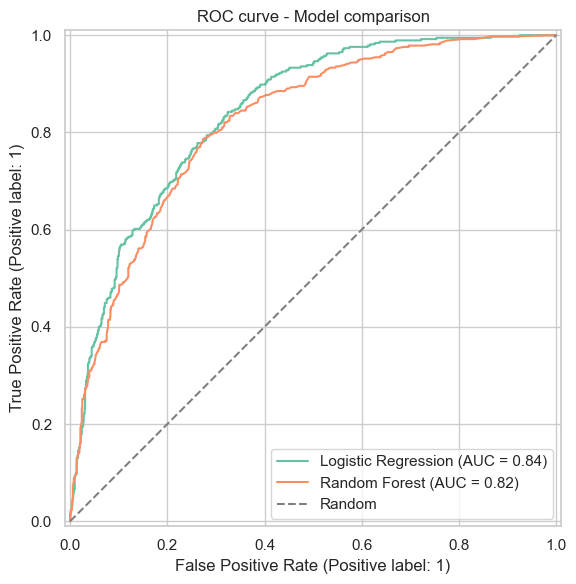

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in fitted_pipelines:
    RocCurveDisplay.from_predictions(
        y_test,
        predictions[model_name]["proba"],
        name=model_name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC curve - Model comparison")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "classification_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Chọn và lưu model tốt nhất

Model được xếp hạng theo thứ tự: F1-score của lớp churn, Recall của lớp churn, sau đó ROC-AUC. Quy tắc này được xác định trước để lựa chọn nhất quán với mục tiêu giữ chân khách hàng, thay vì chọn tùy ý dựa trên metric có kết quả đẹp nhất.

Theo quy tắc trên, **Logistic Regression** được chọn làm model tốt nhất. Mặc dù Accuracy thấp hơn Random Forest, mô hình phát hiện được tỷ lệ khách churn cao hơn đáng kể và đạt F1-score tốt hơn. Đây là lựa chọn phù hợp khi chi phí bỏ sót churn được xem là quan trọng.

Toàn bộ pipeline, bao gồm imputer, scaler, encoder và estimator, được lưu vào `models/best_model.joblib`. Nhờ vậy, dữ liệu mới có thể được truyền trực tiếp vào model với cấu trúc cột ban đầu mà không phải thực hiện preprocessing thủ công. File metadata lưu tên model, quy tắc lựa chọn, threshold, random state và metric để kết quả có thể kiểm tra lại.

Threshold `0.5` ở đây chỉ là điểm tham chiếu kỹ thuật. Đây chưa phải threshold tối ưu cho kinh doanh; notebook 04 sẽ đánh giá nhiều threshold dựa trên Precision, Recall, F1, số khách hàng bị flag và giả định chi phí/lợi ích.

In [11]:
best_model_name = model_comparison.loc[0, "model"]
best_pipeline = fitted_pipelines[best_model_name]
best_metrics = model_comparison.loc[0].to_dict()

best_model_path = MODELS_DIR / "best_model.joblib"
joblib.dump(best_pipeline, best_model_path)

metadata = {
    "best_model": best_model_name,
    "selection_rule": "Highest churn F1, then churn recall, then ROC-AUC",
    "default_threshold": 0.5,
    "random_state": RANDOM_STATE,
    "test_size": split_config["test_size"],
    "metrics": {
        key: float(value) if isinstance(value, (np.floating, float)) else int(value) if isinstance(value, (np.integer, int)) else value
        for key, value in best_metrics.items()
        if key != "model"
    },
}

with (MODELS_DIR / "best_model_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

print("Best model:", best_model_name)
print("Saved model:", best_model_path)
display(model_comparison.iloc[[0]])

Best model: Logistic Regression
Saved model: d:\Customer-Churn-DM\models\best_model.joblib


,model,accuracy,precision_churn_yes,recall_churn_yes,f1_churn_yes,roc_auc,flagged_customers
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841502,581


## 8. Feature importance và model interpretation

Sau OneHotEncoder, một biến phân loại có thể tạo thành nhiều feature, ví dụ `Contract` được tách thành các category riêng. Vì vậy, tên feature sau preprocessing được lấy trực tiếp từ `ColumnTransformer.get_feature_names_out()` để bảo đảm coefficient hoặc importance được ghép đúng cột.

### Logistic Regression coefficient

Coefficient dương làm tăng log-odds churn, còn coefficient âm làm giảm log-odds churn khi các feature khác được giữ cố định. Trị tuyệt đối càng lớn cho thấy feature có ảnh hưởng mạnh hơn trong mô hình. Do numeric feature đã được chuẩn hóa, coefficient giữa các biến số có thể so sánh tương đối hợp lý hơn.

### Random Forest feature importance

`feature_importances_` phản ánh mức giảm impurity mà feature đóng góp qua toàn bộ các cây. Giá trị lớn cho thấy feature được model sử dụng nhiều để phân tách dữ liệu, nhưng không cho biết feature làm tăng hay giảm churn. Importance kiểu này cũng có thể thiên về biến có nhiều điểm chia hoặc nhiều category.

Các kết quả interpretation giúp kiểm tra xem mô hình có học các tín hiệu hợp lý và nhất quán với EDA hay không. Tuy nhiên, chúng mô tả quan hệ dự đoán trong dữ liệu, không chứng minh quan hệ nhân quả.

In [12]:
feature_importance_tables = {}

for model_name, pipeline in fitted_pipelines.items():
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    estimator = pipeline.named_steps["model"]

    if hasattr(estimator, "coef_"):
        importance = estimator.coef_[0]
        importance_type = "coefficient"
    else:
        importance = estimator.feature_importances_
        importance_type = "feature_importance"

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance,
        "absolute_importance": np.abs(importance),
    }).sort_values("absolute_importance", ascending=False)

    feature_importance_tables[model_name] = importance_df
    safe_name = model_name.lower().replace(" ", "_")
    importance_df.to_csv(REPORTS_DIR / f"{safe_name}_{importance_type}.csv", index=False)

    print(f"\nTop features - {model_name}")
    display(importance_df.head(15))


Top features - Logistic Regression


,feature,importance,absolute_importance
0,numeric__tenure,-1.141091,1.141091
39,categorical__Contract_Two year,-0.766446,0.766446
17,categorical__InternetService_Fiber optic,0.715756,0.715756
1,numeric__MonthlyCharges,-0.677256,0.677256
37,categorical__Contract_Month-to-month,0.662997,0.662997
16,categorical__InternetService_DSL,-0.617657,0.617657
2,numeric__TotalCharges,0.474357,0.474357
36,categorical__StreamingMovies_Yes,0.282577,0.282577
26,categorical__DeviceProtection_No internet service,-0.270347,0.270347
20,categorical__OnlineSecurity_No internet service,-0.270347,0.270347



Top features - Random Forest


,feature,importance,absolute_importance
2,numeric__TotalCharges,0.141983,0.141983
0,numeric__tenure,0.129347,0.129347
1,numeric__MonthlyCharges,0.121771,0.121771
37,categorical__Contract_Month-to-month,0.069567,0.069567
19,categorical__OnlineSecurity_No,0.037229,0.037229
39,categorical__Contract_Two year,0.033122,0.033122
28,categorical__TechSupport_No,0.032858,0.032858
44,categorical__PaymentMethod_Electronic check,0.027665,0.027665
17,categorical__InternetService_Fiber optic,0.027030,0.027030
22,categorical__OnlineBackup_No,0.016827,0.016827


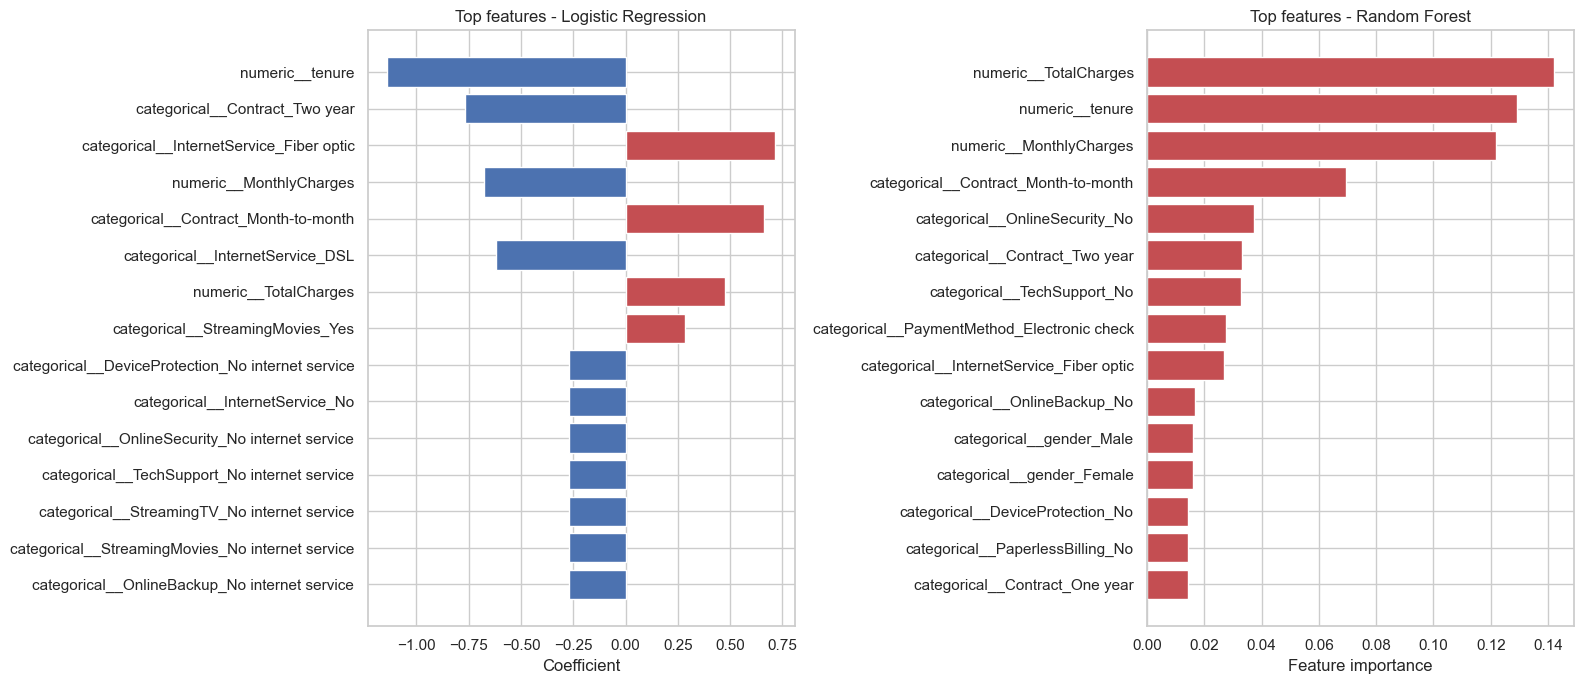

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, fitted_pipelines):
    top_features = feature_importance_tables[model_name].head(15).sort_values("absolute_importance")
    colors = ["#c44e52" if value > 0 else "#4c72b0" for value in top_features["importance"]]
    ax.barh(top_features["feature"], top_features["importance"], color=colors)
    ax.set_title(f"Top features - {model_name}")
    ax.set_xlabel("Coefficient" if model_name == "Logistic Regression" else "Feature importance")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "classification_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Lưu ý khi diễn giải:** với one-hot encoding đầy đủ, coefficient của từng category được diễn giải trong bối cảnh các category còn lại và regularization của mô hình; không nên xem một hệ số riêng lẻ như tác động nhân quả tuyệt đối. Các feature tương quan như `tenure`, `MonthlyCharges` và `TotalCharges` cũng có thể chia sẻ thông tin, làm độ lớn coefficient thay đổi. Với Random Forest, importance nên được dùng để xếp hạng tín hiệu ban đầu; các phương pháp như permutation importance hoặc SHAP có thể được bổ sung nếu cần diễn giải sâu hơn.

## 9. Lưu prediction trên tập test

Notebook lưu `customerID`, nhãn churn thực tế, nhãn dự đoán và xác suất churn của cả hai model trên tập test. File này có ba mục đích:

1. Cho phép truy vết từng dự đoán về đúng khách hàng.
2. Hỗ trợ kiểm tra các trường hợp False Positive và False Negative.
3. Cung cấp xác suất đầu vào cho việc thử nhiều threshold mà không cần huấn luyện lại model.

Xác suất churn là giá trị quan trọng hơn nhãn 0/1 cố định vì nó cho phép doanh nghiệp xếp hạng khách hàng theo mức rủi ro. Ví dụ, khi ngân sách retention có giới hạn, doanh nghiệp có thể ưu tiên nhóm xác suất cao nhất thay vì liên hệ toàn bộ khách hàng bị flag tại threshold 0.5.

In [14]:
test_predictions = pd.DataFrame({
    id_column: id_test.reset_index(drop=True),
    "actual_churn": y_test.reset_index(drop=True),
})

for model_name in fitted_pipelines:
    safe_name = model_name.lower().replace(" ", "_")
    test_predictions[f"{safe_name}_prediction"] = predictions[model_name]["pred"]
    test_predictions[f"{safe_name}_probability"] = predictions[model_name]["proba"]

test_predictions.to_csv(REPORTS_DIR / "classification_test_predictions.csv", index=False)

display(test_predictions.head())
print("Saved rows:", len(test_predictions))

,customerID,actual_churn,logistic_regression_prediction,logistic_regression_probability,random_forest_prediction,random_forest_probability
0,4376-KFVRS,0,0,0.117088,0,0.000000
1,2754-SDJRD,0,1,0.852378,1,0.736667
2,9917-KWRBE,0,0,0.146488,0,0.060000
3,0365-GXEZS,0,1,0.660506,0,0.316667
4,9385-NXKDA,0,0,0.060881,0,0.003333


Saved rows: 1409


## 10. Classification Summary

### Kết quả chính

| Model | Accuracy | Precision churn | Recall churn | F1 churn | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.738 | 0.504 | 0.783 | 0.614 | 0.842 |
| Random Forest | 0.786 | 0.629 | 0.471 | 0.538 | 0.822 |

Logistic Regression được chọn vì đạt F1 và Recall của lớp churn cao hơn. Model phát hiện khoảng 78.3% khách churn trong tập test, nhưng Precision khoảng 50.4% cho thấy gần một nửa nhóm bị flag không thực sự churn. Đây không nhất thiết là kết quả xấu nếu chi phí tiếp cận khách hàng thấp hơn chi phí mất khách, nhưng cần được lượng hóa bằng giả định kinh doanh.

Random Forest đạt Accuracy và Precision cao hơn, nghĩa là các cảnh báo churn của model đáng tin cậy hơn, nhưng Recall thấp cho thấy model quá thận trọng ở threshold 0.5. Kết quả này minh họa rõ việc một model có Accuracy cao hơn chưa chắc phù hợp hơn với mục tiêu retention.

### Kết luận kỹ thuật

- Pipeline xử lý numeric và categorical features mà không học thông tin từ tập test.
- `class_weight='balanced'` giúp Logistic Regression chú ý đến lớp churn và cải thiện Recall.
- Model tốt nhất đã được lưu dưới dạng pipeline hoàn chỉnh, kèm metadata và prediction trên tập test.
- Kết quả hiện tại chỉ dựa trên một train/test split và hai baseline model; chưa thực hiện cross-validation hoặc hyperparameter tuning mở rộng.
- Feature importance cho biết tín hiệu dự đoán, không chứng minh nguyên nhân khiến khách hàng churn.

### Hướng chuyển tiếp

Threshold 0.5 chưa phải quyết định kinh doanh cuối cùng. Notebook 04 sẽ sử dụng xác suất từ Logistic Regression để vẽ ROC và Precision-Recall curve, thử threshold từ 0.1 đến 0.9, đo số khách hàng bị flag và mô phỏng chi phí/lợi ích. Mục tiêu là chọn threshold có Recall đủ cao nhưng Precision không quá thấp và phù hợp với ngân sách retention.